In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Read CSV, handle European decimal and group structure
data = pd.read_csv('måledatafinal.csv')

#append to np arrays
old0 = np.array(data.iloc[1:7, 0], dtype=float)
old2 = np.array(data.iloc[1:7, 1], dtype=float)
old48 = np.array(data.iloc[1:7, 2], dtype=float)
old168 = np.array(data.iloc[1:7, 3], dtype=float)

wo0 = np.array(data.iloc[8:14, 0], dtype=float)
wo2 = np.array(data.iloc[8:14, 1], dtype=float)
wo48 = np.array(data.iloc[8:14, 2], dtype=float)
wo168 = np.array(data.iloc[8:14, 3], dtype=float)

new0 = np.array(data.iloc[15:21, 0], dtype=float)
new2 = np.array(data.iloc[15:21, 1], dtype=float)
new48 = np.array(data.iloc[15:21, 2], dtype=float)
new168 = np.array(data.iloc[15:21, 3], dtype=float)

only0 = np.array(data.iloc[22:28, 0], dtype=float)
only2 = np.array(data.iloc[22:28, 1], dtype=float)
only48 = np.array(data.iloc[22:28, 2], dtype=float)
only168 = np.array(data.iloc[22:28, 3], dtype=float)

long0 = np.array(data.iloc[30:35, 0], dtype=float)
long2 = np.array(data.iloc[30:35, 1], dtype=float)
long48 = np.array(data.iloc[30:35, 2], dtype=float)
long168 = np.array(data.iloc[30:35, 3], dtype=float)



In [2]:
#curvefit the means to an exponential model
from scipy.optimize import curve_fit


x = np.array([0, 2, 48, 168])
y_old = np.array([old0, old2, old48, old168])
y_wo = np.array([wo0, wo2, wo48, wo168])
y_new = np.array([new0, new2, new48, new168])
y_only = np.array([only0, only2, only48, only168])
y_long = np.array([long0, long2, long48, long168])

#the percentual creep from initial length
perc_old = (y_old - old0) / old0 * 100
perc_wo = (y_wo - wo0) / wo0 * 100
perc_new = (y_new - new0) / new0 * 100
perc_only = (y_only - only0) / only0 * 100
perc_long = (y_long - long0) / long0 * 100



In [24]:
# --- Model: y = A * (1 - exp(-t / tau)) ---
# A   : asymptotic value (plateau)
# tau : time constant (controls how fast it converges)
def model(t, A, tau):
    return A * (1 - np.exp(-t / tau))

# Initial guesses
p0 = [-0.16, 20.0]

prints = []
 
def fitData(x, data, model, p0, title=""):
    y = data.mean(axis=1)  # average across samples
    y_err = np.std(data, axis=1, ddof=1)  # sample std dev (ddof=1 for n-1)
    # Curve fit
    popt, pcov = curve_fit(model, x, y, p0=p0, maxfev=10000)
    A_fit, tau_fit = popt
    perr = np.sqrt(np.diag(pcov))  # standard errors
    #print contraction at -0.1hour
    print(model(-0.5,popt[0], popt[1]))    
    print(f"A   = {A_fit:.6f} ± {perr[0]:.6f}")
    print(f"tau = {tau_fit:.4f}  ± {perr[1]:.4f} h")
    # Goodness of fit
    y_pred = model(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot
    print(f"  R²  = {r_squared:.8f}")
    print("=" * 45)

    # Predicted vs actual
    print("\n  t (h)   |  y_actual   |  y_fitted   |  residual")
    print("  --------|-------------|-------------|----------")
    for xi, yi, yp in zip(x, y, y_pred):
        print(f"  {xi:>6}  |  {yi:>10.7f} |  {yp:>10.7f} |  {yi - yp:+.2e}")
 
    # --- Plot ---
    t_fine = np.linspace(0, 200, 500)
    y_fine = model(t_fine, *popt)
 
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(x, y, yerr=y_err,
            fmt='o',                  # circle markers
            color='steelblue',
            ecolor='steelblue',
            elinewidth=1.5,
            capsize=5,                # horizontal caps on error bars
            capthick=1.5,
            zorder=5,
            label='Measured data (mean ± 1σ)')

    ax.scatter(x, y, color='steelblue', zorder=5, s=80, label='Measured data')
    ax.plot(t_fine, y_fine, color='tomato', linewidth=2,
          label=f'Fit: A={A_fit:.4f}, τ={tau_fit:.2f} h')
    ax.axhline(A_fit, color='gray', linestyle='--', linewidth=1,
           label=f'Asymptote: {A_fit:.4f}')
 
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Length contraction (%)')
    ax.set_title(f'Exponential fit — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

0.02861869693089182
A   = -0.133614 ± 0.012173
tau = 2.5763  ± 0.9948 h
  R²  = 0.95336353

  t (h)   |  y_actual   |  y_fitted   |  residual
  --------|-------------|-------------|----------
       0  |   0.0000000 |  -0.0000000 |  +0.00e+00
       2  |  -0.0721378 |  -0.0721378 |  +7.68e-09
      48  |  -0.1508289 |  -0.1336136 |  -1.72e-02
     168  |  -0.1163983 |  -0.1336136 |  +1.72e-02


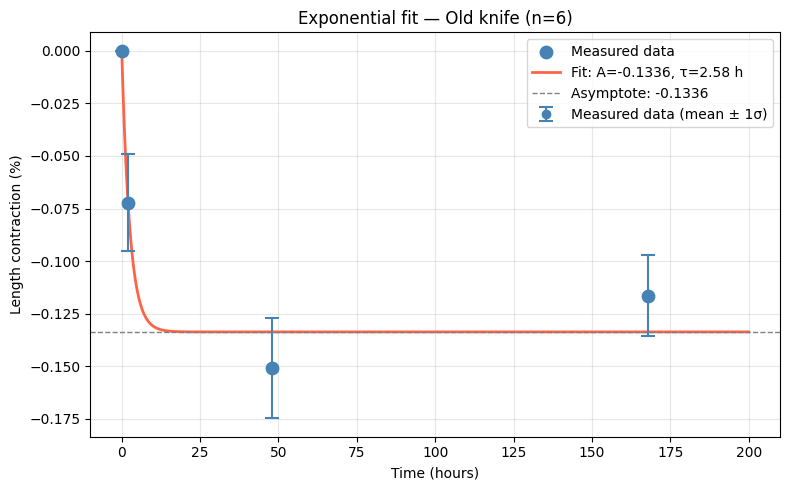

In [25]:
fitData(x, data=perc_old, model=model, p0=p0, title="Old knife (n=6)")

A   = -0.102664 ± 0.008711
tau = 3.3658  ± 1.2916 h
  R²  = 0.96062555

  t (h)   |  y_actual   |  y_fitted   |  residual
  --------|-------------|-------------|----------
       0  |   0.0000000 |  -0.0000000 |  +0.00e+00
       2  |  -0.0459929 |  -0.0459932 |  +3.43e-07
      48  |  -0.1149825 |  -0.1026637 |  -1.23e-02
     168  |  -0.0903452 |  -0.1026638 |  +1.23e-02


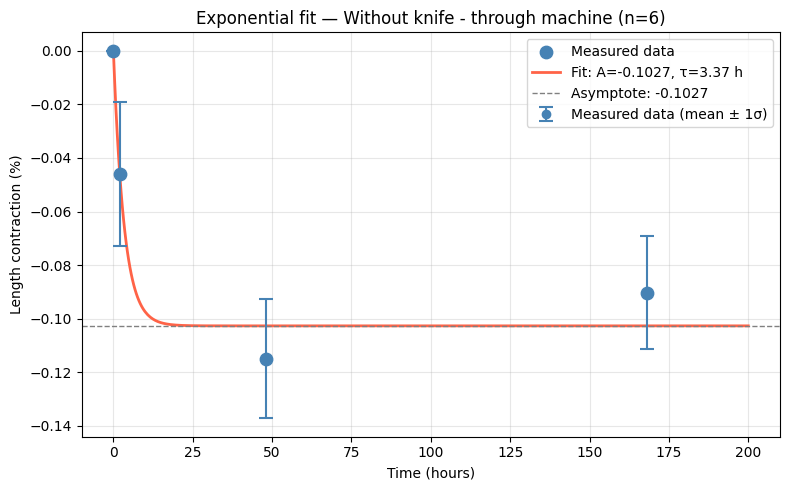

In [5]:
fitData(x, data=perc_wo, model=model, p0=p0, title="Without knife - through machine (n=6)")

A   = -0.145108 ± 0.005216
tau = 2.5585  ± 0.3894 h
  R²  = 0.99243735

  t (h)   |  y_actual   |  y_fitted   |  residual
  --------|-------------|-------------|----------
       0  |   0.0000000 |  -0.0000000 |  +0.00e+00
       2  |  -0.0787024 |  -0.0787024 |  -2.38e-09
      48  |  -0.1377317 |  -0.1451083 |  +7.38e-03
     168  |  -0.1524850 |  -0.1451083 |  -7.38e-03


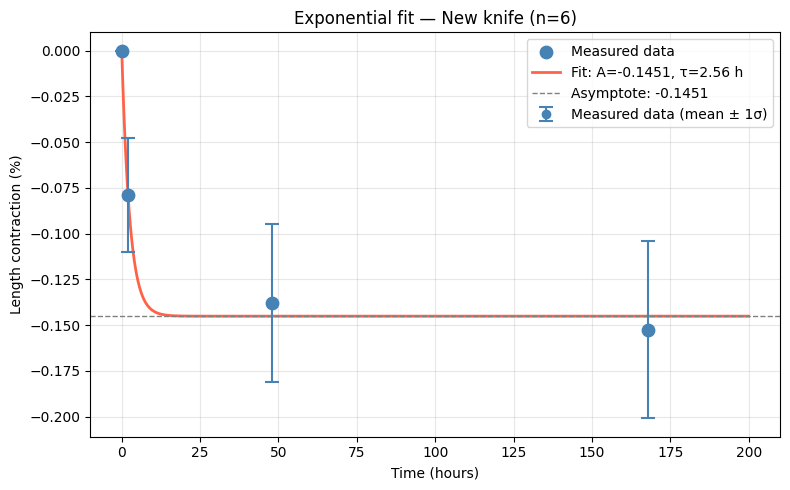

In [6]:
fitData(x, data=perc_new, model=model, p0=p0, title="New knife (n=6)")

A   = -0.137902 ± 0.019600
tau = 40.8351  ± 18.7752 h
  R²  = 0.95187108

  t (h)   |  y_actual   |  y_fitted   |  residual
  --------|-------------|-------------|----------
       0  |   0.0000000 |  -0.0000000 |  +0.00e+00
       2  |  -0.0297255 |  -0.0065914 |  -2.31e-02
      48  |  -0.0921555 |  -0.0953347 |  +3.18e-03
     168  |  -0.1367588 |  -0.1356485 |  -1.11e-03


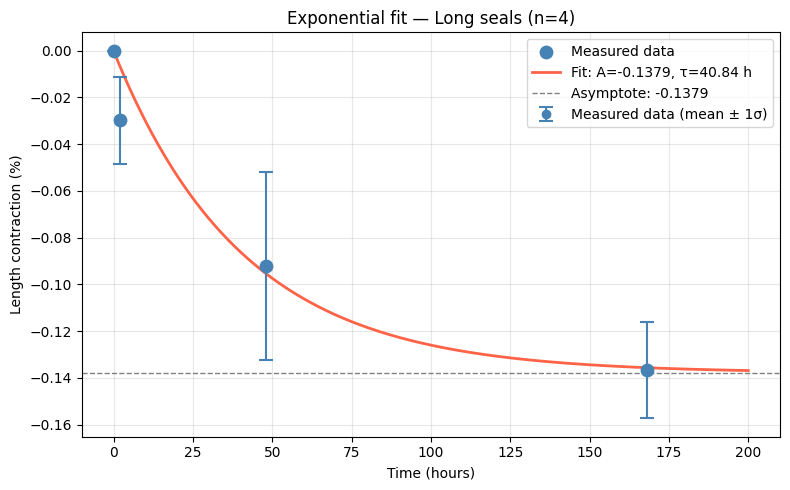

In [7]:
fitData(x=x, data=perc_long, model=model, p0=p0, title="Long seals (n=4)")

A   = -349.091501 ± 3668856.594467
tau = 816418.3871  ± 8580998091.3266 h
  R²  = 0.94735851

  t (h)   |  y_actual   |  y_fitted   |  residual
  --------|-------------|-------------|----------
       0  |   0.0000000 |  -0.0000000 |  +0.00e+00
       2  |  -0.0063984 |  -0.0008552 |  -5.54e-03
      48  |  -0.0080655 |  -0.0205237 |  +1.25e-02
     168  |  -0.0753216 |  -0.0718276 |  -3.49e-03


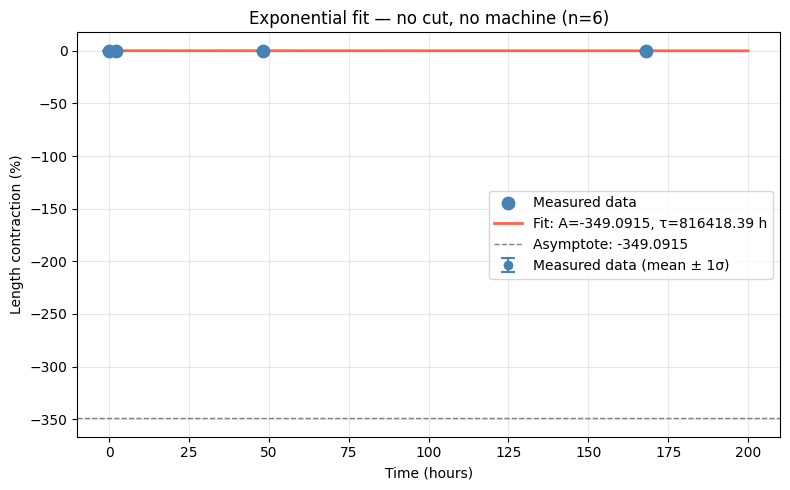

In [8]:
fitData(x, data=perc_only, model=model, p0=p0, title="no cut, no machine (n=6)")

In [9]:
dL = 0.69e-3
L0 = 200e-3
E = 900 #MPa
stress = E * (dL / L0)  
print(f"Applied stress: {stress:.2f} MPa")
crosssection = (2.385*3.55*10**-6)
print(f"Applied force: {stress* 10**6 * crosssection:.2f} N")

Applied stress: 3.10 MPa
Applied force: 26.29 N
